# Demo: Rover Response Optimization

This notebook shows how variables in an fmdtools model can be optimized for resilience.

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```


In [1]:
from fmdtools.sim.sample import SampleApproach, FaultSample, FaultDomain, ParameterDomain
import fmdtools.analyze as an
import fmdtools.sim.propagate as prop
from fmdtools.sim.search import ParameterSimProblem
import matplotlib.pyplot as plt
import multiprocessing as mp
import time

Model is in defined model_main.py

In [2]:
from fmdtools_examples.navigating_rover.model_main import Rover, RoverParam

## Optimization

Here we define the optimization problem for the rover.

We use a parallel pool, staged execution, and minimal tracking options to lower computational cost as much as possible.

In [3]:
mdl = Rover(sp={'end_condition': ''}, track={'flows':{"ground":"all", "pos": "all"}})
#rover_prob = search.ProblemInterface("rover_problem", mdl, pool=mp.Pool(5), staged=True, track=track)

In [4]:
mdl.h

time:                         array(151)
flows.ground.r.probdens:      array(151)
flows.ground.s.in_bound:      array(151)
flows.ground.sp.phases:       array(151)
flows.ground.sp.start_time:   array(151)
flows.ground.sp.end_time:     array(151)
flows.ground.sp.track_times:  array(151)
flows.ground.sp.dt:           array(151)
flows.ground.sp.units:        array(151)
flows.ground.sp.end_condition: array(151)
flows.ground.sp.use_local:    array(151)
flows.ground.sp.with_loadings: array(151)
flows.ground.sp.run_stochastic: array(151)
flows.ground.sp.track_pdf:    array(151)
flows.ground.c.r.probdens:    array(151)
flows.ground.ga.points.start.s.on: array(151)
flows.ground.ga.points.start.s.near: array(151)
flows.ground.ga.points.end.s.on: array(151)
flows.ground.ga.points.end.s.near: array(151)
flows.pos.s.x:                array(151)
flows.pos.s.y:                array(151)
flows.pos.s.vel:              array(151)
flows.pos.s.ux:               array(151)
flows.pos.s.uy:               arr

In [5]:
mdl.p

RoverParam(ground=GroundParam(linetype='sine', amp=1.0, period=6.283185307179586, radius=20.0, x_start=10.0, y_end=10.0, x_min=0.0, x_max=30.0, x_res=0.1, path_buffer_on=0.2, path_buffer_poor=0.3, path_buffer_near=0.4, dest_buffer_on=1.0, dest_buffer_near=2.0), correction=ResCorrection(ub_f=10.0, lb_f=-1.0, ub_t=10.0, lb_t=0.0, ub_d=2.0, lb_d=-2.0, cor_d=0.0, cor_t=0.0, cor_f=0.0), degradation=DegParam(friction=0.0, drift=0.0), drive_modes={'mode_options': 'set'})

Here we will be optimizing over faults in the drive system at 3 points during the drive simulation interval:

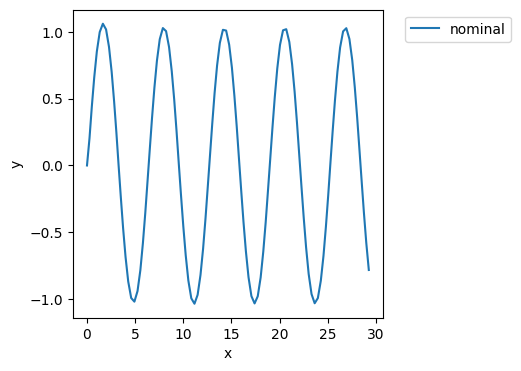

In [6]:
endresults, mdlhist = prop.nominal(Rover())
phasemap = an.phases.from_hist(mdlhist)
fault_domain = FaultDomain(mdl)
fault_domain.add_all_fxnclass_modes('Drive')
fault_sample = FaultSample(fault_domain, phasemap['plan_path'])
fault_sample.add_fault_phases('drive',  args=(3,))
fig, ax = mdlhist.plot_trajectories("flows.pos.s.x", "flows.pos.s.y")

The variables are the correction factors int the fault management: 

In [7]:
pd = ParameterDomain(RoverParam)
pd.add_variables("correction.cor_f", "correction.cor_d", "correction.cor_t", lims={"correction.cor_f":(0, 1), 
                                                                                         "correction.cor_d":(-1, 1),
                                                                                         "correction.cor_t":(-1, 1)})
pd

ParameterDomain with:
 - variables: {'correction.cor_f': (0, 1), 'correction.cor_d': (-1, 1), 'correction.cor_t': (-1, 1)}
 - constants: {}
 - parameter_initializer: RoverParam

Now we setup the optimization problem using `ParameterSimProblem`

We can define multiple objectives, below we will use the end distance and total_deviation from `classify`. 

In [8]:
class RoverProb(ParameterSimProblem):
    def init_problem(self, **kwargs):
        self.add_parameterdomain(pd)
        self.add_sim(mdl, "fault_sample", fault_sample, **kwargs)
        self.add_result_objective('f1', 'classify.end_dist')
        self.add_result_objective('f2', 'classify.tot_deviation')

In [9]:
rover_prob = RoverProb()
rover_prob

RoverProb with:
VARIABLES
 -correction.cor_f                                              nan
 -correction.cor_d                                              nan
 -correction.cor_t                                              nan
OBJECTIVES
 -f1                                                            nan
 -f2                                                            nan

Here we do some basic timing:

In [10]:
rover_prob.f1(0.5,0.5,0.5)
a=time.time()
rover_prob.f1(0.6,0.5,0.5)
t=time.time()-a
t

4.043263912200928

In [11]:
rover_prob

RoverProb with:
VARIABLES
 -correction.cor_f                                           0.6000
 -correction.cor_d                                           0.5000
 -correction.cor_t                                           0.5000
OBJECTIVES
 -f1                                                       129.8820
 -f2                                                         2.5205

Alternatively, we can use:

In [12]:
rover_prob.time_execution(0.7,0.5,0.5)

4.076462268829346

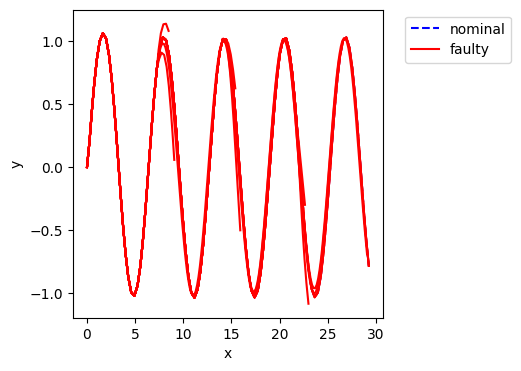

In [13]:
fig, ax = rover_prob.hist.plot_trajectories("flows.pos.s.x", "flows.pos.s.y")

In [14]:
rover_prob

RoverProb with:
VARIABLES
 -correction.cor_f                                           0.7000
 -correction.cor_d                                           0.5000
 -correction.cor_t                                           0.5000
OBJECTIVES
 -f1                                                       132.2823
 -f2                                                         2.5270

### Rover Optimization: 

In [15]:
from pymoo.optimize import minimize
from pymoo.algorithms.soo.nonconvex.pattern import PatternSearch
from pymoo.problems.functional import FunctionalProblem
import numpy as np

Covert optimization problem into a pymoo problem

In [21]:
from multiprocessing import Pool
rover_prob = RoverProb(pool=Pool(4), auto_close_pool=False)

n_var = len(rover_prob.variables)
x_low = np.array([])
x_up = np.array([])
for bound in rover_prob.parameterdomain.variables.values():
    x_low = np.append(x_low, bound[0])
    x_up = np.append(x_up, bound[1])
    
obj = [lambda x: rover_prob.f1(*x)]
pymoo_prob = FunctionalProblem(n_var, obj, xl = x_low, xu= x_up)

In [22]:
arg={}
pymoo_prob._evaluate([0.7,0.5,0.5],arg)

In [23]:
arg

{'F': array([132.28226465]),
 'G': array([], dtype=float64),
 'H': array([], dtype=float64)}

Run optimizaion algorithm..

In [24]:
algorithm=PatternSearch(x0=np.array([0.7,0.5,0.5])) 

In [25]:
from pymoo.termination import get_termination
# early termination 
termination = get_termination("n_eval", 13)
res = minimize(pymoo_prob, algorithm, termination=termination, verbose=True)

n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |        1 |  1.322823E+02 |  1.322823E+02
     2 |        7 |  1.307473E+02 |  1.292124E+02
     3 |       13 |  1.268410E+02 |  1.244696E+02


In [26]:
res.X

array([0.325, 0.5  , 0.5  ])

In [27]:
opt_x = [ 0.16970361, -0.78522209,  0.10777078]

### Results visualization

Here we look at the optimized results and compare with the starting results:

In [28]:
rover_prob.f1(0.16970361, -0.78522209,  0.10777078)

np.float64(122.37205579225862)

RoverProb with:
VARIABLES
 -correction.cor_f                                           0.1697
 -correction.cor_d                                          -0.7852
 -correction.cor_t                                           0.1078
OBJECTIVES
 -f1                                                       122.3721
 -f2                                                         2.5435

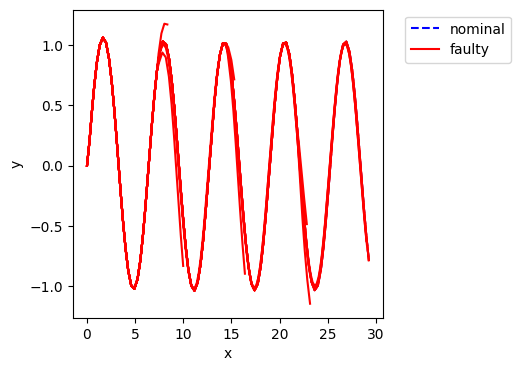

In [29]:
fig, ax = rover_prob.hist.plot_trajectories("flows.pos.s.x", "flows.pos.s.y")
rover_prob

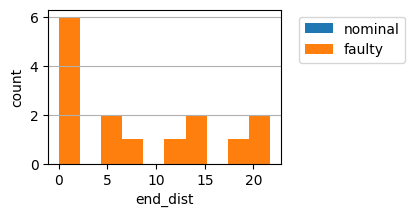

In [30]:
fig, ax = rover_prob.res.plot_metric_dist('end_dist')

starting solution:

In [31]:
rover_prob.f1(0.7,0.5,0.5)

np.float64(132.28226465048797)

RoverProb with:
VARIABLES
 -correction.cor_f                                           0.7000
 -correction.cor_d                                           0.5000
 -correction.cor_t                                           0.5000
OBJECTIVES
 -f1                                                       132.2823
 -f2                                                         2.5270

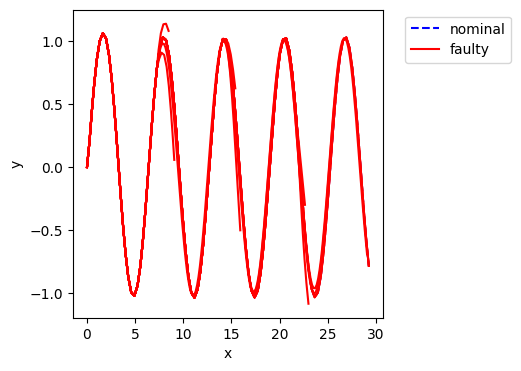

In [32]:
fig, ax = rover_prob.hist.plot_trajectories("flows.pos.s.x", "flows.pos.s.y")
rover_prob

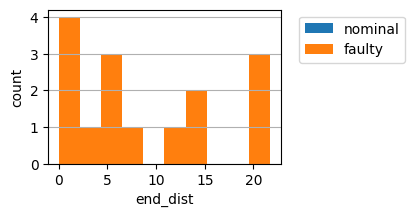

In [33]:
fig, ax = rover_prob.res.plot_metric_dist('end_dist')

As shown, while the optimized correction factors don't mitigate all scenarios, they do increase the number of scenarios that are mitigated.

In [34]:
rover_prob.close_pool()